# Robot Delivery Challenge

## 1. Problem Description

A small delivery robot works on an `8 x 8` city map. In each delivery run, the robot starts somewhere on the map, picks up a package from one depot, and delivers it to another depot. Some cells are blocked, and every map is a bit different.

If you were writing a regular program, you could inspect the map, find a path, and follow it. In this challenge, we ask a different question: can a model learn this behavior from solved examples?

There is no trial-and-error training loop here. Treat this as an ordinary supervised learning problem: the training file already contains examples of what should be done in different situations.

Each solved example is a sequence of small decisions:

```text
what the robot sees -> correct next action
```

The model studies these examples during training. Later, it must choose actions in new delivery runs where the answers are not provided.

### Your Mission

Train a model that can:

1. Learn from provided demonstrations.
2. Choose a useful next action from the current observation.
3. Finish a complete delivery run.
4. Generalize to validation and test scenarios that were not shown as demonstrations.

### The Challenge

The demonstration budget is deliberately small. A good solution should not only remember the examples, but learn something that transfers to new maps.

A single wrong action can move the robot into situations that were rare in the demonstrations, so high action accuracy does not always mean high full-run success.


## 2. Load The Kaggle Data

The data files are attached to this Kaggle notebook as an input dataset. The cell below lists available input files and finds the folder containing:

- `train_demos.pkl`
- `valid_scenarios.pkl`
- `test_scenarios.pkl`

When you create a saved Kaggle notebook version, the final `submission.csv` will be written to the working directory.


In [2]:
# The following code will only execute
# successfully when compression is complete

import kagglehub

# Download latest version
path = kagglehub.competition_download('ioai-2026-home-task-2')

print("Path to competition files:", path)

100%|██████████| 284k/284k [00:00<00:00, 551kB/s]

Extracting files...
Path to competition files: C:\Users\raian\.cache\kagglehub\competitions\ioai-2026-home-task-2


In [3]:
from pathlib import Path
import os

DATA_DIR = Path(path)
print("Using data dir:", DATA_DIR)
print("Data files:", sorted(path.name for path in DATA_DIR.iterdir()))

Using data dir: C:\Users\raian\.cache\kagglehub\competitions\ioai-2026-home-task-2
Data files: ['test_scenarios.pkl', 'train_demos.pkl', 'valid_scenarios.pkl']


## 3. Understanding the Task Simulator

To make the task easier to explore, we provide a small simulator. You can use it to inspect a scenario, replay a solved delivery run, and watch the solutions produced by your model.

The task is a small grid delivery problem.

- The grid size is `8 x 8`.
- There are six depot cells: `A`, `B`, `C`, `D`, `E`, `F`.
- One depot contains the package.
- Another depot is the destination.
- The robot must move to the package, pick it up, move to the destination, and drop it off.
- Walls block movement.

The simulator is included directly in this notebook so it works as a single Google Colab file. The visual helper below can also save and display animated GIFs.


In [4]:
import json
import pickle
import random
from collections import Counter
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from IPython.display import Image as NotebookImage, display
from PIL import Image as PILImage, ImageDraw
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

GRID_SIZE = 8
N_DEPOTS = 6
MAX_STEPS = 120
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ACTION_NAMES = {
    0: "south",
    1: "north",
    2: "east",
    3: "west",
    4: "pickup",
    5: "dropoff",
}

ACTION_DELTAS = {
    0: (1, 0),
    1: (-1, 0),
    2: (0, 1),
    3: (0, -1),
}

DEPOT_NAMES = ["A", "B", "C", "D", "E", "F"]

print("data dir:", DATA_DIR)
print("device:", DEVICE)


data dir: C:\Users\raian\.cache\kagglehub\competitions\ioai-2026-home-task-2
device: cuda


In [5]:
class DeliverySimulator8x8:
    """Run one 8x8 delivery scenario."""

    def reset(self, scenario: dict[str, Any]) -> tuple[int, int, int, int]:
        """Start a scenario and return the compact state."""
        self.step_count = 0
        self.carrying = False
        self.walls = {tuple(cell) for cell in scenario["walls"]}
        self.depots = [tuple(cell) for cell in scenario["depots"]]
        self.agent_pos = tuple(scenario["agent_pos"])
        self.package_location = int(scenario["package_location"])
        self.destination = int(scenario["destination"])
        return self.state()

    def state(self) -> tuple[int, int, int, int]:
        """Return row, column, package field, and destination."""
        package_field = N_DEPOTS if self.carrying else self.package_location
        return int(self.agent_pos[0]), int(self.agent_pos[1]), int(package_field), int(self.destination)

    def can_enter(self, row: int, col: int) -> bool:
        """Check whether the robot can occupy a cell."""
        return 0 <= row < GRID_SIZE and 0 <= col < GRID_SIZE and (row, col) not in self.walls

    def valid_action_mask(self) -> np.ndarray:
        """Return the currently valid actions."""
        row, col, _, destination = self.state()
        mask = np.zeros(6, dtype=bool)
        for action, (dr, dc) in ACTION_DELTAS.items():
            mask[action] = self.can_enter(row + dr, col + dc)
        mask[4] = (not self.carrying) and self.agent_pos == self.depots[self.package_location]
        mask[5] = self.carrying and self.agent_pos == self.depots[destination]
        return mask

    def observation(self) -> dict[str, Any]:
        """Build the model observation for the current state."""
        row, col, package_field, destination = self.state()
        carrying = package_field == N_DEPOTS
        dest_row, dest_col = self.depots[destination]
        target_row, target_col = (dest_row, dest_col) if carrying else self.depots[package_field]

        grid = np.zeros((6, GRID_SIZE, GRID_SIZE), dtype=np.float32)
        for wr, wc in self.walls:
            grid[0, wr, wc] = 1.0
        for dr, dc in self.depots:
            grid[1, dr, dc] = 1.0
        grid[2, row, col] = 1.0
        if not carrying:
            pr, pc = self.depots[package_field]
            grid[3, pr, pc] = 1.0
        grid[4, dest_row, dest_col] = 1.0
        grid[5, :, :] = float(carrying)

        blocked_moves = [float(not self.can_enter(row + dr, col + dc)) for dr, dc in ACTION_DELTAS.values()]
        vector = np.array(
            [
                row / (GRID_SIZE - 1),
                col / (GRID_SIZE - 1),
                package_field / N_DEPOTS,
                destination / (N_DEPOTS - 1),
                float(carrying),
                target_row / (GRID_SIZE - 1),
                target_col / (GRID_SIZE - 1),
                (target_row - row) / (GRID_SIZE - 1),
                (target_col - col) / (GRID_SIZE - 1),
                *blocked_moves,
            ],
            dtype=np.float32,
        )
        return {"grid": grid, "vector": vector, "action_mask": self.valid_action_mask(), "state": self.state()}

    def step(self, action: int) -> tuple[tuple[int, int, int, int], bool, bool, dict[str, Any]]:
        """Apply one action and report run status."""
        action = int(action)
        done = False
        info = {"invalid_pickup_or_dropoff": False}

        if action in ACTION_DELTAS:
            dr, dc = ACTION_DELTAS[action]
            row, col = self.agent_pos[0] + dr, self.agent_pos[1] + dc
            if self.can_enter(row, col):
                self.agent_pos = (row, col)
        elif action == 4 and (not self.carrying) and self.agent_pos == self.depots[self.package_location]:
            self.carrying = True
        elif action == 5 and self.carrying and self.agent_pos == self.depots[self.destination]:
            done = True
            self.carrying = False
            self.package_location = self.destination
        elif action in (4, 5):
            info["invalid_pickup_or_dropoff"] = True
        else:
            raise ValueError(f"unknown action: {action}")

        self.step_count += 1
        return self.state(), done, self.step_count >= MAX_STEPS and not done, info

    def render(self) -> str:
        """Return an ASCII rendering of the current grid."""
        grid = [["." for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]
        for row, col in self.walls:
            grid[row][col] = "#"
        for i, (row, col) in enumerate(self.depots):
            grid[row][col] = DEPOT_NAMES[i]

        agent_row, agent_col = self.agent_pos
        grid[agent_row][agent_col] = "T*" if self.carrying else "T"
        rows = [" ".join(f"{cell:>2}" for cell in row) for row in grid]
        package_name = "in taxi" if self.carrying else DEPOT_NAMES[self.package_location]
        rows.append(f"package={package_name}, destination={DEPOT_NAMES[self.destination]}")
        return "\n".join(rows)


In [6]:
CELL_SIZE = 56
FRAME_FOOTER = 44
DEPOT_COLORS = ["#ef4444", "#3b82f6", "#22c55e", "#f59e0b", "#a855f7", "#06b6d4"]


def draw_delivery_frame(simulator, step=0, action_name="start"):
    """Render the current simulator state as a PIL image."""
    width = GRID_SIZE * CELL_SIZE
    height = GRID_SIZE * CELL_SIZE + FRAME_FOOTER
    image = PILImage.new("RGB", (width, height), "#f8fafc")
    draw = ImageDraw.Draw(image)

    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            x0, y0 = col * CELL_SIZE, row * CELL_SIZE
            x1, y1 = x0 + CELL_SIZE, y0 + CELL_SIZE
            fill = "#334155" if (row, col) in simulator.walls else "#f8fafc"
            draw.rectangle([x0, y0, x1, y1], fill=fill, outline="#cbd5e1")

    target_id = simulator.destination if simulator.carrying else simulator.package_location
    for depot_id, (row, col) in enumerate(simulator.depots):
        x0, y0 = col * CELL_SIZE + 8, row * CELL_SIZE + 8
        x1, y1 = x0 + CELL_SIZE - 16, y0 + CELL_SIZE - 16
        color = DEPOT_COLORS[depot_id]
        draw.rounded_rectangle([x0, y0, x1, y1], radius=10, fill=color)
        draw.text((x0 + 14, y0 + 9), DEPOT_NAMES[depot_id], fill="white")
        if depot_id == target_id:
            draw.rounded_rectangle([x0 - 4, y0 - 4, x1 + 4, y1 + 4], radius=14, outline="#111827", width=4)

    row, col = simulator.agent_pos
    cx, cy = col * CELL_SIZE + CELL_SIZE // 2, row * CELL_SIZE + CELL_SIZE // 2
    draw.ellipse([cx - 18, cy - 18, cx + 18, cy + 18], fill="#111827")
    draw.text((cx - 5, cy - 8), "T", fill="white")
    if simulator.carrying:
        draw.rectangle([cx + 10, cy - 24, cx + 25, cy - 9], fill="#f97316", outline="#9a3412")

    package = "in robot" if simulator.carrying else DEPOT_NAMES[simulator.package_location]
    footer = f"step {step:02d} | action: {action_name} | package: {package} -> {DEPOT_NAMES[simulator.destination]}"
    draw.rectangle([0, GRID_SIZE * CELL_SIZE, width, height], fill="#e2e8f0")
    draw.text((12, GRID_SIZE * CELL_SIZE + 14), footer, fill="#0f172a")
    return image


def show_delivery_gif(scenario, actions, path="delivery_run.gif", duration=450):
    """Save and display an animated GIF for one action sequence."""
    simulator = DeliverySimulator8x8()
    simulator.reset(scenario)
    frames = [draw_delivery_frame(simulator)]
    for step, action in enumerate(actions, start=1):
        simulator.step(action)
        frames.append(draw_delivery_frame(simulator, step, ACTION_NAMES[action]))
    frames[0].save(path, save_all=True, append_images=frames[1:], duration=duration, loop=0)
    display(NotebookImage(filename=path))


## 4. Dataset

### 4.1 Training Examples

The training file `data/train_demos.pkl` contains solved delivery runs.

Each run stores what the robot observed at each step and which action was taken. You can think of it as many small practice questions: given this observation, what should the next action be?

**Data Format:**

```python
{
    "trajectories": [
        {
            "layout_id": str,
            "episode_seed": int,
            "scenario": dict,
            "observations": [
                {
                    "grid": np.array,       # shape: (6, 8, 8)
                    "vector": np.array,     # shape: (13,)
                    "action_mask": np.array,# shape: (6,)
                    "state": tuple
                },
                ...
            ],
            "actions": [int, ...],       # action IDs 0-5
            "success": bool,
            "num_steps": int
        },
        ...
    ]
}
```

### 4.2 Validation and Test Scenarios

You are also provided with:

- `data/valid_scenarios.pkl`
- `data/test_scenarios.pkl`

These files contain delivery scenarios without answer actions. Run your trained model on them and check whether the package is delivered successfully.


In [7]:
with (DATA_DIR / "train_demos.pkl").open("rb") as f:
    train_data = pickle.load(f)
with (DATA_DIR / "valid_scenarios.pkl").open("rb") as f:
    valid_scenarios = pickle.load(f)
with (DATA_DIR / "test_scenarios.pkl").open("rb") as f:
    test_scenarios = pickle.load(f)

train_trajectories = train_data["trajectories"]
steps = [t["num_steps"] for t in train_trajectories]

print("Loaded data")
print("  solved training runs:", len(train_trajectories))
print("  validation scenarios:", len(valid_scenarios))
print("  test scenarios:", len(test_scenarios))
print("  supervised training samples:", sum(steps))
print("  average demonstration length:", f"{np.mean(steps):.2f}")
print("  solved-run success rate:", f"{100 * np.mean([t['success'] for t in train_trajectories]):.1f}%")


Loaded data
  solved training runs: 400
  validation scenarios: 200
  test scenarios: 1600
  supervised training samples: 5327
  average demonstration length: 13.32
  solved-run success rate: 100.0%


Solved example
  layout_id: train_0000
  episode_seed: 100000
  num_steps: 23
  actions: ['north', 'north', 'north', 'east', 'east', 'east', 'east', 'east', 'pickup', 'south', 'west', 'south', 'south', 'south', 'south', 'south', 'west', 'west', 'west', 'west', 'west', 'west', 'dropoff']

Observation
  grid shape: (6, 8, 8)
  vector shape: (13,)
  valid actions: ['south', 'north', 'east']

Initial frame
 .  .  .  .  .  .  .  A
 .  #  .  .  E  #  D  .
 .  .  .  .  .  .  .  #
 .  #  T  .  .  #  .  .
 F  .  .  #  #  .  .  .
 .  .  .  .  .  #  .  .
 B  .  .  .  .  .  .  .
 .  .  .  .  .  .  .  .
package=A, destination=B

Animated solved run


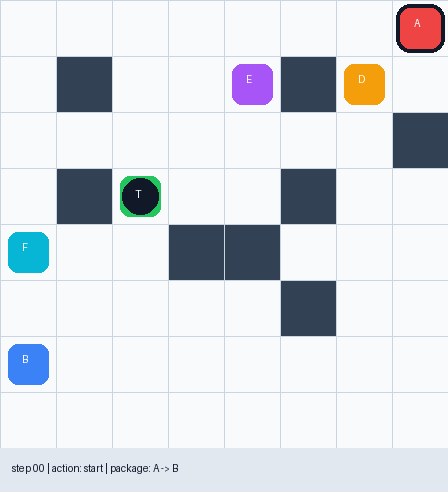

In [8]:
example = train_trajectories[0]
print("Solved example")
print("  layout_id:", example["layout_id"])
print("  episode_seed:", example["episode_seed"])
print("  num_steps:", example["num_steps"])
print("  actions:", [ACTION_NAMES[a] for a in example["actions"]])

obs0 = example["observations"][0]
print("\nObservation")
print("  grid shape:", obs0["grid"].shape)
print("  vector shape:", obs0["vector"].shape)
print("  valid actions:", [ACTION_NAMES[i] for i, ok in enumerate(obs0["action_mask"]) if ok])

simulator = DeliverySimulator8x8()
simulator.reset(example["scenario"])
print("\nInitial frame")
print(simulator.render())

print("\nAnimated solved run")
show_delivery_gif(example["scenario"], example["actions"], path="solved_example.gif")


## 5. Task

### 5.1 Objective

Your goal is to maximize successful deliveries.

Train an action model that:

1. Takes the current observation as input.
2. Predicts the next action.
3. Runs step by step until the delivery is completed or the step limit is reached.
4. Achieves high success rate on validation and test scenarios.

### 5.2 Input and Output

**Input observation:**

- `grid`: `6 x 8 x 8` tensor with walls, depots, robot position, package position, destination, and carrying flag.
- `vector`: 13 numerical features with normalized position and target information.
- `action_mask`: 6 binary values showing which actions are currently valid.

**Output action:**

A single integer from `0` to `5`:

| id | action |
|---:|---|
| 0 | south |
| 1 | north |
| 2 | east |
| 3 | west |
| 4 | pickup |
| 5 | dropoff |

### 5.3 Learning Setup

This is ordinary supervised learning from demonstrations. In imitation-learning language, this setup is also called behavioral cloning.

1. Turn solved runs into `(observation, action)` examples.
2. Train a model to predict the action.
3. Run the trained model on new scenarios.
4. Improve the model when full delivery runs fail.

### 5.4 Improving Beyond the Baseline

The baseline below is intentionally simple. Better solutions may come from better input representation, a model that matches the structure of the task, stronger training, and careful analysis of failed runs.


## 6. Submission

### 6.1 What to Submit

Submit a file named `submission.csv` with two columns:

```csv
id,actions
test_0000__300000,"[1,1,2,4,0,5]"
```

### 6.2 Prediction Format

**Fields:**

- `id`: scenario identifier in the format `layout_id__episode_seed`.
- `actions`: JSON list of action IDs, each integer from `0` to `5`.

A shorter action list is allowed. If the delivery is not completed within the submitted actions and the step limit, the scenario is counted as failed.

### 6.3 How Evaluation Works

1. The evaluator reads your predicted actions from `submission.csv`.
2. For each test scenario, it starts from the hidden scenario state.
3. It replays your actions step by step.
4. Success means the package is delivered to the destination.

### 6.4 Constraints

- Use the provided demonstrations for training.
- Do not use answer actions for validation or test scenarios.
- Do not generate additional labeled runs with search, planning, or another solver.
- Your final prediction process should be deterministic.
- Your submitted notebook should generate `submission.csv` from scratch.
- Rule-based or hard-coded solutions may be reviewed by the Scientific Committee.


## 7. Scoring

### 7.1 Official Metric

The official competition metric is **Success Rate (SR) on the official test scenarios**. Higher is better.

```text
SR = (# successful deliveries) / (# total scenarios)
```

A scenario is successful if the package is delivered to the destination within the step limit.

### 7.2 Diagnostics

The notebook also reports:

- `avg_steps`: average number of steps used per scenario.
- `avg_invalid_pickup_or_dropoff`: average number of invalid pickup/dropoff attempts.

These diagnostics are useful for debugging, but they are not the official score.


## 8. Baseline & Training

Below is a complete starter solution using a small MLP. It is meant to run quickly and show the full workflow, not to be a strong final solution.

**Baseline Key Limitations:**

- The map is flattened into one long vector, so the model does not really see it as a map.
- The model is small and has no special way to reason about paths, walls, or delivery stages.
- Rare decisions such as `pickup` and `dropoff` appear much less often than movement actions.
- The model learns individual steps, but one early mistake can still break the whole delivery.

**Your task:** improve the model and training procedure to achieve better delivery success.


### 8.1 Create Supervised Training Samples


In [9]:
def flatten_observation(obs):
    """Return the 4-channel map the CNN consumes (inference path)."""
    g = obs["grid"].astype(np.float32)
    carrying = g[5, 0, 0] > 0.5
    return np.stack([1.0 - g[0], g[2], g[4] if carrying else g[3], g[5]], axis=0)


# action IDs: 0=south(+1,0)  1=north(-1,0)  2=east(0,+1)  3=west(0,-1)  4=pickup  5=dropoff
ROT = [
    [0, 1, 2, 3, 4, 5],   # k=0: identity
    [2, 3, 1, 0, 4, 5],   # k=1: 90 deg
    [1, 0, 3, 2, 4, 5],   # k=2: 180 deg
    [3, 2, 0, 1, 4, 5],   # k=3: 270 deg
]
FLIP = [0, 1, 3, 2, 4, 5]  # mirror left-right: east <-> west


def build_subpath_samples(runs):
    """Relabel every sub-path of every demonstration segment."""
    free_grids, samples = [], []
    for run_idx, run in enumerate(runs):
        obs_list, acts = run["observations"], run["actions"]
        free_grids.append((1.0 - obs_list[0]["grid"][0]).astype(np.float32))

        start = 0
        for t, a in enumerate(acts):
            if a not in (4, 5):          # a segment ends at a pickup or a dropoff
                continue
            cells = [tuple(obs_list[i]["state"][:2]) for i in range(start, t + 1)]
            carrying = float(obs_list[start]["grid"][5, 0, 0])

            # keep the pickup/dropoff itself: robot is ON the target
            samples.append((run_idx, cells[-1], cells[-1], carrying, int(a)))

            # every ordered pair i < j: acts[start+i] is an optimal first move toward cells[j]
            for i in range(len(cells) - 1):
                for j in range(i + 1, len(cells)):
                    if cells[i] == cells[j]:
                        continue         # guard: never label "standing on target" with a move
                    samples.append((run_idx, cells[i], cells[j], carrying, int(acts[start + i])))
            start = t + 1
    return free_grids, samples


class SubPathDataset(Dataset):
    """Sub-path relabeled demos, expanded 8x by the symmetries of the square."""

    def __init__(self, runs):
        self.free_grids, self.samples = build_subpath_samples(runs)

    def __len__(self):
        return 8 * len(self.samples)

    def __getitem__(self, idx):
        run_idx, (r, c), (tr, tc), carrying, action = self.samples[idx // 8]
        k, do_flip = (idx % 8) % 4, (idx % 8) // 4

        robot = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float32)
        robot[r, c] = 1.0
        target = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.float32)
        target[tr, tc] = 1.0
        grid = np.stack([
            self.free_grids[run_idx],                                   # ch0: free space
            robot,                                                      # ch1: robot
            target,                                                     # ch2: relabeled target
            np.full((GRID_SIZE, GRID_SIZE), carrying, dtype=np.float32) # ch3: carrying
        ], axis=0)

        if do_flip:
            grid = np.flip(grid, axis=2)
            action = FLIP[action]
        grid = np.rot90(grid, k, axes=(1, 2))
        action = ROT[k][action]

        return (
            torch.tensor(np.ascontiguousarray(grid), dtype=torch.float32),
            torch.tensor(action, dtype=torch.long),
        )


train_dataset = SubPathDataset(train_trajectories)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# closed-form augmented counts: under D4 each base move maps to each of the 4 move
# classes exactly twice; pickup/dropoff map to themselves all 8 times.
base = Counter(s[4] for s in train_dataset.samples)
n_moves = sum(v for a, v in base.items() if a < 4)
action_counts = {a: (2 * n_moves if a < 4 else 8 * base.get(a, 0)) for a in range(6)}

print("base samples:", len(train_dataset.samples), "| augmented:", len(train_dataset))
print("action counts:", {ACTION_NAMES[k]: v for k, v in action_counts.items()})

base samples: 19075 | augmented: 152600
action counts: {'south': 36550, 'north': 36550, 'east': 36550, 'west': 36550, 'pickup': 3200, 'dropoff': 3200}


### 8.2 Define Action Model

This baseline uses a small MLP. Before improving it, ask yourself: is a flat list of numbers the best way to describe a map?


In [10]:
import torch
import torch.nn as nn
import numpy as np

class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.c1 = nn.Conv2d(c, c, 3, padding = 1)
        self.b1 = nn.BatchNorm2d(c)
        self.c2 = nn.Conv2d(c, c, 3, padding = 1)
        self.b2 = nn.BatchNorm2d(c)

    def forward (self, x):
        h = torch.relu(self.b1(self.c1(x)))
        h = self.b2(self.c2(h))
        return torch.relu(x+h)

class PolicyNet(nn.Module):
    def __init__(self, in_ch=3, c=64, n_blocks=14):
        super().__init__()
        self.stem = nn.Sequential(nn.Conv2d(in_ch, c, 3, padding=1), nn.BatchNorm2d(c), nn.ReLU())
        self.blocks = nn.Sequential(*[ResBlock(c) for _ in range(n_blocks)])
        self.head = nn.Conv2d(c, 6, 1)

    def forward(self, x):
        robot = x[:, 1:2]
        xin = torch.cat([x[:, 0:1], x[:, 2:4]], dim=1)   # free, target, carrying
        h = self.blocks(self.stem(xin))
        return (self.head(h) * robot).sum(dim=(2,3))





class CNNActionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(4, 32, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU()
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.relu3 = nn.ReLU()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(4096, 128)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(128, 6)

    def forward(self, x):
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.conv3(x)
        x = self.relu3(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu4(x)
        x = self.fc2(x)
        return x

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = PolicyNet().to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
counts = torch.tensor([action_counts[i] for i in range(6)], dtype=torch.float32)
weights = counts.sum() / (6.0 * counts.clamp(min=1.0))
criterion = nn.CrossEntropyLoss(weight=weights.to(DEVICE))
print("class weights:", weights.tolist())

print(model)
print("parameters:", sum(p.numel() for p in model.parameters()))


class weights: [0.6958504319190979, 0.6958504319190979, 0.6958504319190979, 0.6958504319190979, 7.947916507720947, 7.947916507720947]
PolicyNet(
  (stem): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (blocks): Sequential(
    (0): ResBlock(
      (c1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (b1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (c2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (b2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): ResBlock(
      (c1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (b1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (c2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1

### 8.3 Train the Action Model


In [11]:
# the 8 (k, flip, action-perm) triples, composed exactly as the dataset composes them
D4 = []
for do_flip in (0, 1):
    for k in range(4):
        perm = [ROT[k][FLIP[a] if do_flip else a] for a in range(6)]
        D4.append((k, do_flip, torch.tensor(perm)))

@torch.no_grad()
def model_action(obs):
    model.eval()
    g = flatten_observation(obs)                              # (4, 8, 8)
    views = []
    for k, do_flip, _ in D4:
        t = np.flip(g, axis=2) if do_flip else g
        views.append(np.ascontiguousarray(np.rot90(t, k, axes=(1, 2))))
    x = torch.tensor(np.stack(views), dtype=torch.float32, device=DEVICE)   # (8, 4, 8, 8)
    lt = model(x).cpu()                                       # (8, 6), transformed frames
    logits = torch.stack([lt[i, perm] for i, (_, _, perm) in enumerate(D4)]).sum(0)
    mask = torch.as_tensor(np.asarray(obs["action_mask"]), dtype=torch.bool)
    return int(logits.masked_fill(~mask, -1e9).argmax().item())


def run_delivery(scenario, action_fn, max_steps=MAX_STEPS, render=False):
    """Run an action model on one scenario."""
    simulator = DeliverySimulator8x8()
    simulator.reset(scenario)
    frames, actions = [], []
    invalid_pickup_or_dropoff = 0
    done = False

    if render:
        frames.append(simulator.render())

    for _ in range(max_steps):
        action = int(action_fn(simulator.observation()))
        _, done, timed_out, info = simulator.step(action)
        actions.append(action)
        invalid_pickup_or_dropoff += int(info["invalid_pickup_or_dropoff"])
        if render:
            frames.append(simulator.render())
        if done or timed_out:
            break

    return {
        "success": done,
        "steps": len(actions),
        "invalid_pickup_or_dropoff": invalid_pickup_or_dropoff,
        "actions": actions,
        "frames": frames,
    }


def evaluate_action_model(scenarios, action_fn, limit=None):
    """Evaluate delivery success on a scenario list."""
    results = [run_delivery(s, action_fn) for s in tqdm(scenarios[:limit])]
    return {
        "success_rate": float(np.mean([r["success"] for r in results])),
        "avg_steps": float(np.mean([r["steps"] for r in results])),
        "avg_invalid_pickup_or_dropoff": float(np.mean([r["invalid_pickup_or_dropoff"] for r in results])),
        "results": results,
    }


rng = np.random.default_rng(SEED)


def random_action_model(obs):
    """Sample a random action."""
    return int(rng.integers(6))


def mlp_action_model(obs):
    """Use the trained MLP action model."""
    return model_action(obs)


In [13]:
@torch.no_grad()
def train_action_accuracy():
    """Measure action accuracy on the training examples."""
    model.eval()
    correct = total = 0
    for x, y in DataLoader(train_dataset, batch_size=1024):
        pred = model(x.to(DEVICE)).argmax(dim=1).cpu()
        correct += int((pred == y).sum())
        total += int(y.numel())
    return correct / total

import copy

EPOCHS = 30

model = PolicyNet().to(DEVICE)                      # rebinds the GLOBAL `model`
optimizer = torch.optim.Adam(model.parameters(), lr=2e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
best_sr, best_state = -1.0, None                    # reset PER SEED

for epoch in tqdm(range(1, EPOCHS + 1)):
    model.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        loss = criterion(model(x), y)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
    scheduler.step()

    if epoch >= EPOCHS - 8 and epoch % 4 == 0:      # only the last few, annealed epochs
        sr = evaluate_action_model(valid_scenarios, mlp_action_model, limit=None)["success_rate"]
        if sr >= best_sr:
            best_sr, best_state = sr, copy.deepcopy(model.state_dict())
        print(f"epoch {epoch:02d} | SR {sr:.4f}" + ("  <-- best" if sr == best_sr else ""))

if best_state is not None:
    model.load_state_dict(best_state)


print(f"best validation SR {best_sr:.4f}")

  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/200 [00:00<?, ?it/s]

epoch 24 | SR 0.9850  <-- best


  0%|          | 0/200 [00:00<?, ?it/s]

epoch 28 | SR 0.9850  <-- best
best validation SR 0.9850


In [14]:
@torch.no_grad()
def model_action(obs):
    """Ensemble: len(seed_models) seeds x 8 symmetries."""
    g = flatten_observation(obs)
    views = [np.ascontiguousarray(np.rot90(np.flip(g, axis=2) if f else g, k, axes=(1, 2)))
             for k, f, _ in D4]
    x = torch.tensor(np.stack(views), dtype=torch.float32, device=DEVICE)   # (8, 4, 8, 8)

    logits = torch.zeros(6)
    model.eval()
    lt = model(x).cpu()                                                     # (8, 6)
    logits += torch.stack([lt[i, perm] for i, (_, _, perm) in enumerate(D4)]).sum(0)

    mask = torch.as_tensor(np.asarray(obs["action_mask"]), dtype=torch.bool)
    return int(logits.masked_fill(~mask, -1e9).argmax().item())

### 8.4 Evaluation Functions

Action accuracy is useful, but the main check is successful delivery. A model can make many correct-looking local decisions and still fail after one early mistake.


In [15]:
EVAL_LIMIT = 100  # set to None for all validation scenarios

random_eval = evaluate_action_model(valid_scenarios, random_action_model, limit=EVAL_LIMIT)
mlp_eval = evaluate_action_model(valid_scenarios, mlp_action_model, limit=EVAL_LIMIT)

for name, metrics in [("random", random_eval), ("MLP", mlp_eval)]:
    print(name, {k: v for k, v in metrics.items() if k != "results"})


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

random {'success_rate': 0.04, 'avg_steps': 118.86, 'avg_invalid_pickup_or_dropoff': 38.56}
MLP {'success_rate': 0.98, 'avg_steps': 15.01, 'avg_invalid_pickup_or_dropoff': 0.0}


### 8.5 Inspect One Validation Run


success: True
steps: 18
invalid pickup/dropoff: 0
actions: ['west', 'west', 'west', 'west', 'north', 'north', 'west', 'north', 'north', 'north', 'pickup', 'south', 'west', 'south', 'south', 'south', 'south', 'dropoff']
initial frame:
 #  D  C  .  B  .  .  .
 .  .  .  .  .  #  #  #
 .  .  #  .  .  .  #  .
 .  .  .  .  .  .  .  .
 .  #  .  .  .  .  .  .
 F  .  .  .  .  .  T  .
 .  A  #  .  .  .  E  .
 .  .  .  .  .  .  .  .
package=D, destination=F
final frame:
 #  D  C  .  B  .  .  .
 .  .  .  .  .  #  #  #
 .  .  #  .  .  .  #  .
 .  .  .  .  .  .  .  .
 .  #  .  .  .  .  .  .
 T  .  .  .  .  .  .  .
 .  A  #  .  .  .  E  .
 .  .  .  .  .  .  .  .
package=F, destination=F
animated run:


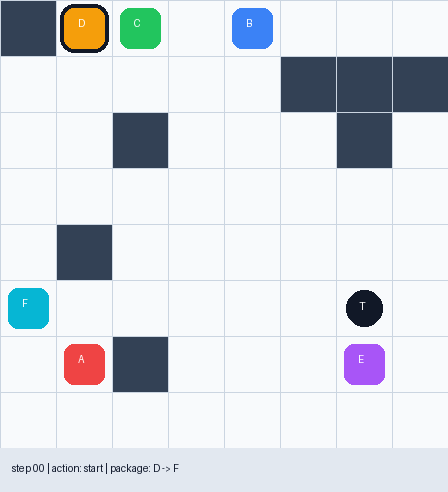

In [16]:
example_run = run_delivery(valid_scenarios[0], mlp_action_model, render=True)
print("success:", example_run["success"])
print("steps:", example_run["steps"])
print("invalid pickup/dropoff:", example_run["invalid_pickup_or_dropoff"])
print("actions:", [ACTION_NAMES[a] for a in example_run["actions"]])
print("initial frame:")
print(example_run["frames"][0])
print("final frame:")
print(example_run["frames"][-1])

print("animated run:")
show_delivery_gif(valid_scenarios[0], example_run["actions"], path="model_run.gif")


  0%|          | 0/200 [00:00<?, ?it/s]

3 failures: [17, 49, 67]


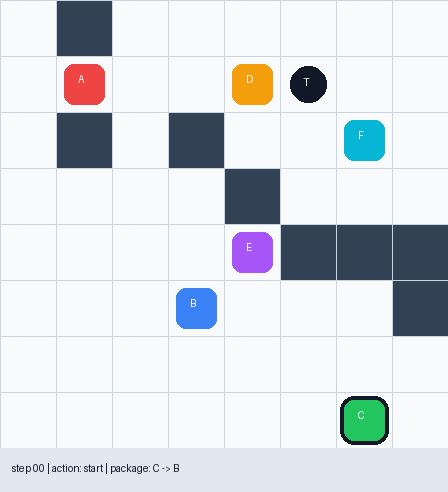

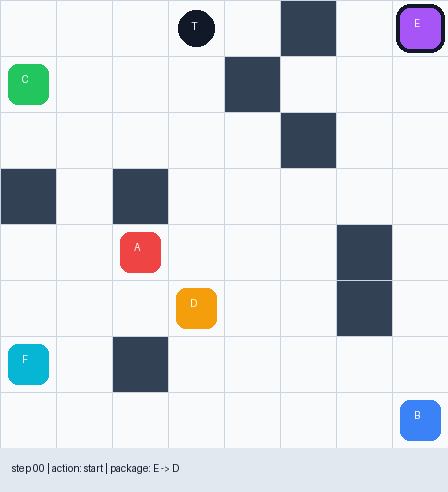

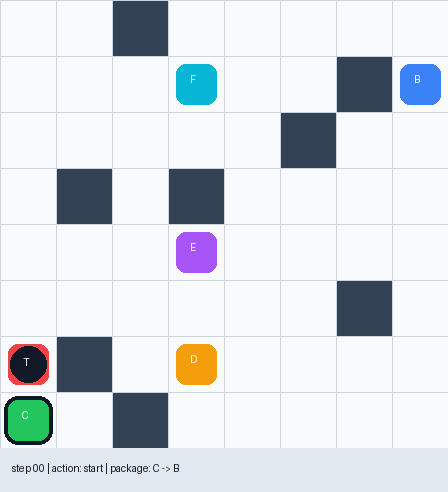

In [ ]:
ev = evaluate_action_model(valid_scenarios, mlp_action_model, limit=None)
fails = [i for i, r in enumerate(ev["results"]) if not r["success"]]
print(len(fails), "failures:", fails)
for i in fails[:3]:
    show_delivery_gif(valid_scenarios[i], ev["results"][i]["actions"], path=f"fail_{i}.gif")

### 8.6 Generate Kaggle Submission File

The test set contains scenarios without answer actions. For Kaggle, submit one CSV row per scenario. The `actions` column stores a JSON list of action IDs.


In [ ]:
def generate_predictions(scenarios, action_fn, limit=None):
    """Generate action sequences for scenarios."""
    predictions = []
    for scenario in tqdm(scenarios[:limit], desc="Generating predictions"):
        result = run_delivery(scenario, action_fn)
        predictions.append({
            "layout_id": scenario["layout_id"],
            "episode_seed": scenario["episode_seed"],
            "actions": result["actions"],
        })
    return predictions


def predictions_to_submission(predictions):
    """Convert predictions to Kaggle submission format."""
    return pd.DataFrame([
        {
            "id": f"{pred['layout_id']}__{pred['episode_seed']}",
            "actions": json.dumps([int(action) for action in pred["actions"]], separators=(",", ":")),
        }
        for pred in predictions
    ])


# Small preview before generating the full submission.
test_predictions_preview = generate_predictions(test_scenarios, mlp_action_model, limit=5)
preview_submission = predictions_to_submission(test_predictions_preview)
preview_submission.head()


Generating predictions:   0%|          | 0/5 [00:00<?, ?it/s]

,id,actions
0,test_0000__300000,"[1,2,2,0,4,1,3,3,1,5]"
1,test_0000__300001,"[2,2,2,1,4,3,3,3,3,3,1,3,3,0,5]"
2,test_0000__300002,"[0,0,4,0,0,2,2,2,0,2,2,0,0,5]"
3,test_0000__300003,"[3,3,3,3,1,1,3,3,3,1,1,1,4,0,0,0,0,0,5]"
4,test_0001__300004,"[3,0,4,1,5]"


In [ ]:
# Generate the full Kaggle submission file.
test_predictions = generate_predictions(test_scenarios, mlp_action_model, limit=None)
submission = predictions_to_submission(test_predictions)
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv", submission.shape)
submission.head()


Generating predictions:   0%|          | 0/1600 [00:00<?, ?it/s]

Saved submission.csv (1600, 2)


,id,actions
0,test_0000__300000,"[1,2,2,0,4,1,3,3,1,5]"
1,test_0000__300001,"[2,2,2,1,4,3,3,3,3,3,1,3,3,0,5]"
2,test_0000__300002,"[0,0,4,0,0,2,2,2,0,2,2,0,0,5]"
3,test_0000__300003,"[3,3,3,3,1,1,3,3,3,1,1,1,4,0,0,0,0,0,5]"
4,test_0001__300004,"[3,0,4,1,5]"


## 9. Hints for Improvement

These are not instructions for one correct solution. Use them as debugging questions after you run the baseline.

### Representation

- Does the input format make walls, targets, and the robot position easy for the model to use?
- Are all parts of the observation equally useful, or should some parts be encoded differently?
- Does flattening the grid hide information that would be obvious on a map?

### Model

- Is the baseline model a good match for map-like input?
- Should the model process the map and the numerical features in the same way?
- Can the model learn both local moves and longer delivery plans?

### Failure Analysis

- Does high action accuracy lead to high delivery success?
- Which scenarios fail most often: before pickup, after pickup, near walls, or near the destination?
- Are there rare actions or rare situations that the model does not learn well?
- When you replay failed scenarios, do the mistakes look random, systematic, or caused by earlier drift?
